$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 4.7

倘若我们事先知晓变量 $x_2$ 无关紧要，就应当针对变量 $x_1$ 采用最优试验设计开展四次试验；反之同理。图 4.7 左侧子图展示了这类设计方案，此处针对每个输入变量采用极小极大设计：$\{(i - 0.5)/4\}_{i=1}^4$。可以发现，将四个试验设计点分别投影至两条坐标轴上时，两个因子各自都会得到四个互不相同的数值。因此，即便试验结束后发现其中某一个因子并无显著影响，该设计方案依旧能够拥有良好的试验效果。

构造具备优良一维投影特性的试验设计十分简便。将每一条坐标轴均划分为 $n$ 个等间距区间。随后，只需保证每行、每列仅存在一个样本点，即可得到所需投影效果，具体形式见图 4.7。拓展至高维情形时，可通过下式实现：

$$
\left\{\frac{\pi_j(i)-0.5}{n}\right\}_{i=1}^n
\tag{4.21}
$$

上式对应设计的第 $j$ 列，其中 $\{\pi_j(1),\dots,\pi_j(n)\}$ 是整数集合 $\{1,\dots,n\}$ 的一组随机排列。这类设计被称作拉丁超立方设计（LHD）。本文采用单元格中心点构造设计，也就是式 (4.21) 中令 $u_{ij}=0.5$ 的形式。

尽管拉丁超立方抽样（LHD）能够实现优质的一维投影，但构造该抽样时所采用的随机置换未必总能具备优良特性。图 4.7 右侧子图展示了一例随机拉丁超立方抽样样本。不难看出该拉丁超立方抽样方案效果较差，原因是两个因子完全相关，并且在试验区域内留下了大片空白区间。可以采用最大最小准则优化拉丁超立方抽样，该准则既可保证良好的空间填充特性，也能实现优质的一维投影，由此得到的设计被称为最大最小拉丁超立方抽样，简称 MmLHD。采用式 (4.18) 中的 TRD 准则：

$$
\min_{D\in\mathcal{L}}\sum_{i=1}^n\sum_{j\neq i}\frac{1}{\|\boldsymbol{x}_i - \boldsymbol{x}_j\|^{2\alpha}}
$$

式中 $\mathcal{L}$ 代表全体拉丁超立方抽样构成的集合。将最大最小准则与拉丁超立方抽样结合是十分合适的组合方式，该方法简洁高效，也使得最大最小拉丁超立方抽样成为计算机试验中应用最为广泛的设计方案。图 4.7 左侧子图中的设计即为最大最小拉丁超立方抽样。

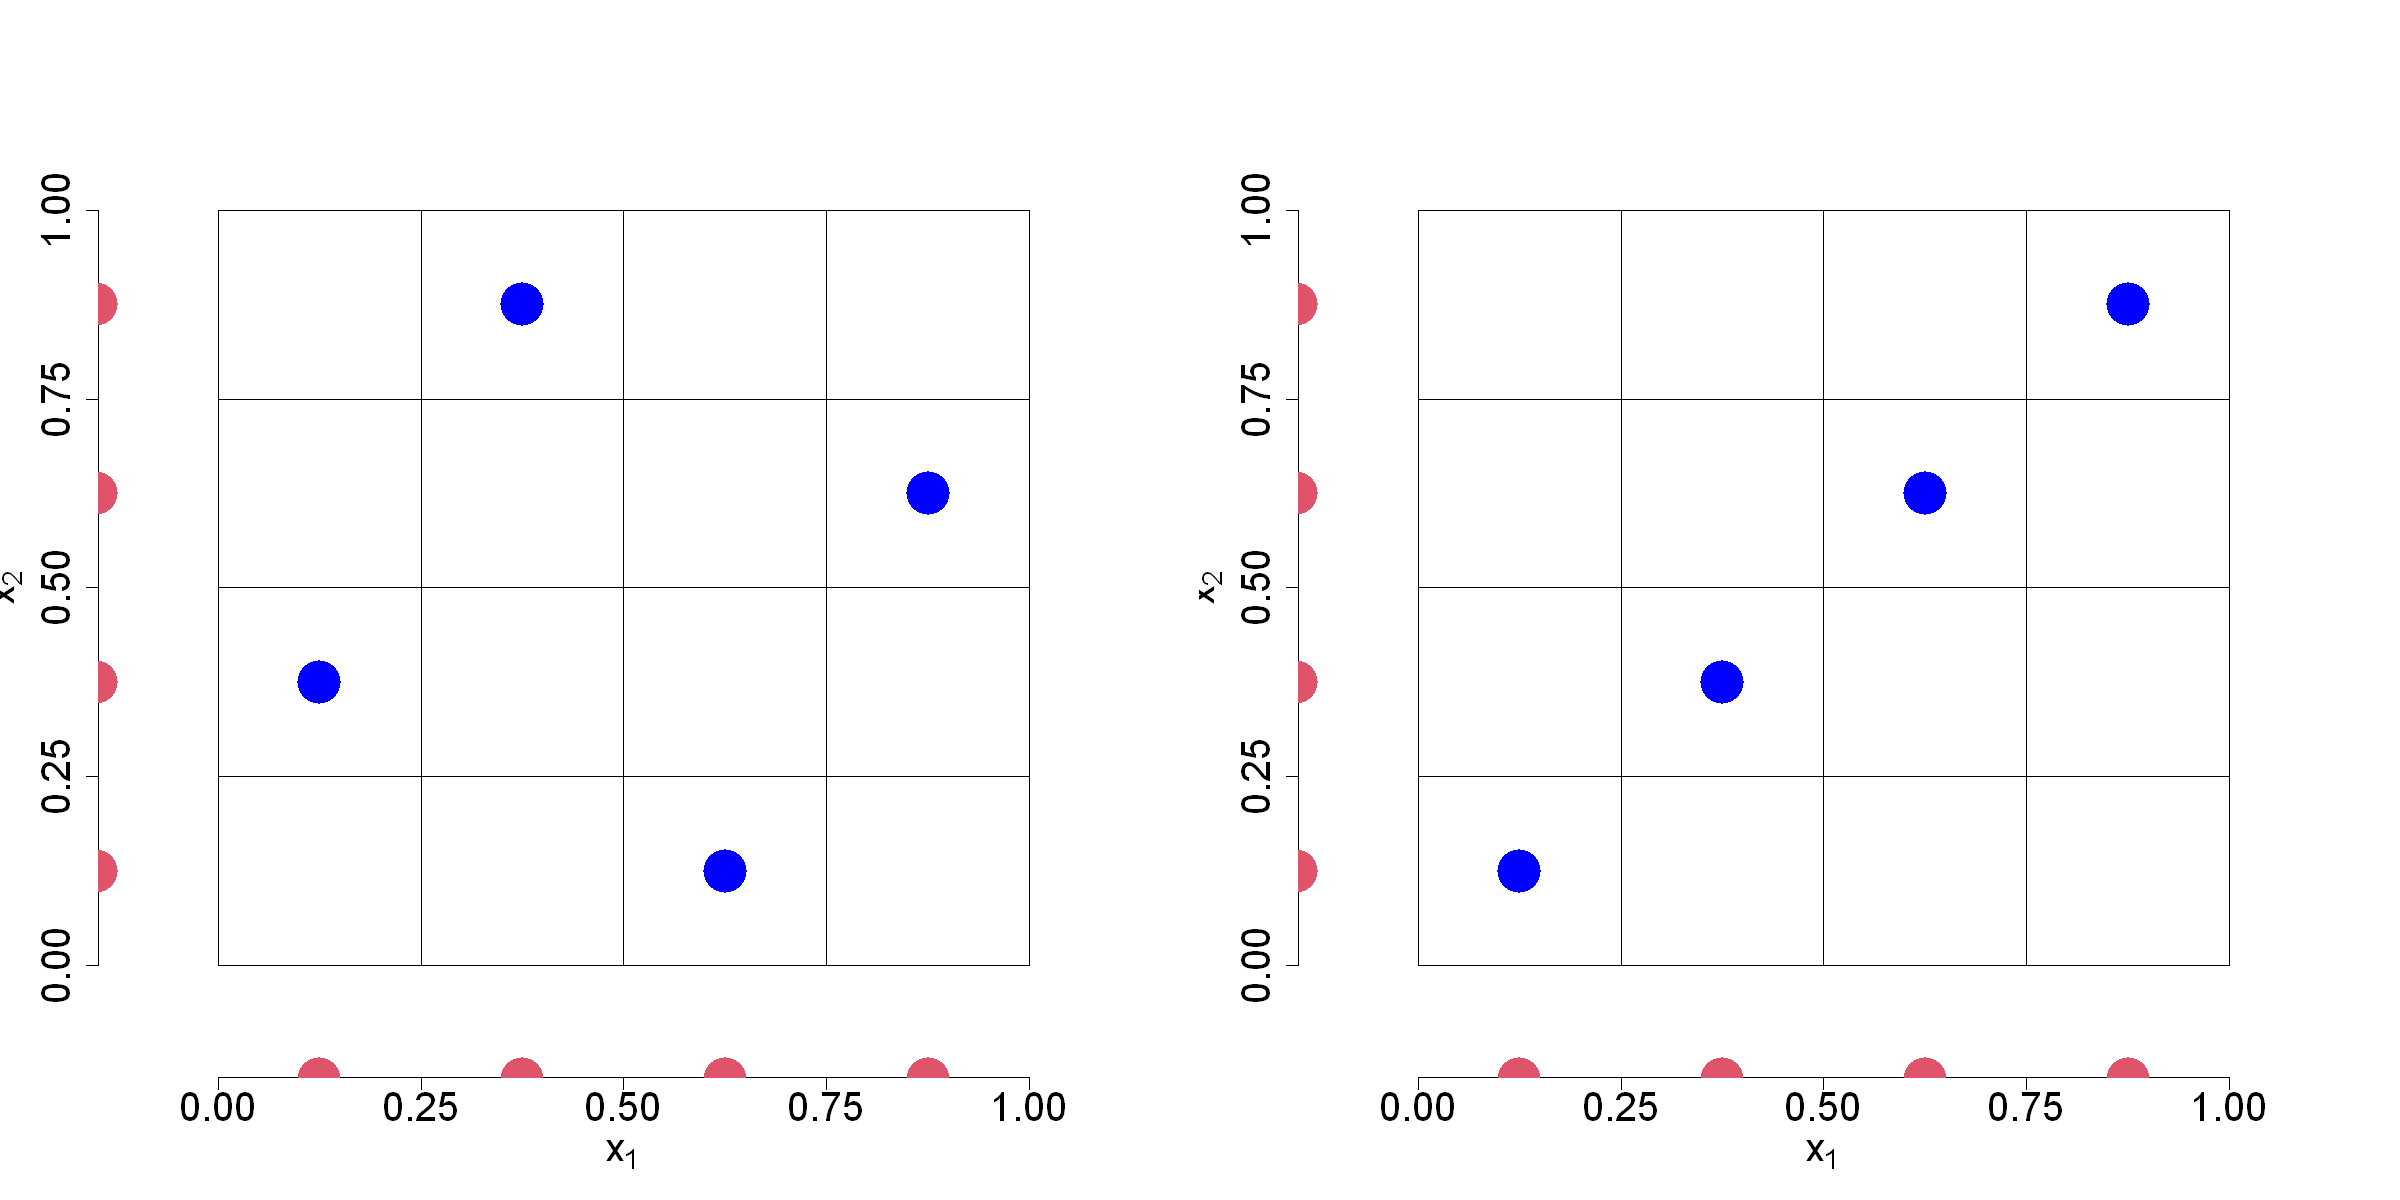

In [2]:
if(!dir.exists("data"))dir.create("data")
if((!file.exists("data/4.7-D.csv"))||(!file.exists("data/4.7-para.csv"))){
  p=2;n=4
  set.seed(1)
  library(SFDesign)
  D1=maximinLHD(n,p)$design # 4x2
  D2=(cbind(1:n,1:n)-.5)/n # 4x2
  write.csv(data.frame(D1=D1,D2=D2),file="data/4.7-D.csv",row.names=FALSE)
  write.csv(data.frame(n=n),file="data/4.7-para.csv",row.names=FALSE)
}

df_D=read.csv("data/4.7-D.csv")
D1=as.matrix(df_D[,paste0("D1.",1:2)])
D2=as.matrix(df_D[,paste0("D2.",1:2)])
para=read.csv("data/4.7-para.csv")
n=para$n

options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
plot(D1,pch=16,xaxt="n",yaxt="n",cex=5,bty="n",col="blue",xlim=c(-.1,1.1),ylim=c(-.1,1.1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2)
axis(1,at=seq(0,1,by=.25),cex.axis=2)
axis(2,at=seq(0,1,by=.25),cex.axis=2)
for(i in 1:(n+1)){
segments((i-1)/n,0,(i-1)/n,1)
segments(0,(i-1)/n,1,(i-1)/n)
}
points(cbind(D1[,1],-.15),col=2,pch=16,cex=5)
points(cbind(-.15,D1[,2]),col=2,pch=16,cex=5)
plot(D2,pch=16,xaxt="n",yaxt="n",cex=5,bty="n",col="blue",xlim=c(-.1,1.1),ylim=c(-.1,1.1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2)
axis(1,at=seq(0,1,by=.25),cex.axis=2)
axis(2,at=seq(0,1,by=.25),cex.axis=2)
for(i in 1:(n+1)){
segments((i-1)/n,0,(i-1)/n,1)
segments(0,(i-1)/n,1,(i-1)/n)
}
points(cbind(D2[,1],-.15),col=2,pch=16,cex=5)
points(cbind(-.15,D2[,2]),col=2,pch=16,cex=5)

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$